In [26]:
import xgboost as xgb 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [7]:
pd.set_option('display.float_format', '{:.0f}'.format)

# Loading and joining the datasets

In [16]:
# Load data
df = pd.read_csv('train.csv')

songs = pd.read_csv('songs.csv')
df = pd.merge(df, songs, on='song_id', how='left')
del songs

# Load and join songs data
members = pd.read_csv('members.csv',parse_dates=['registration_init_time','expiration_date'])
df = pd.merge(df, members, on='msno', how='left')
del members

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 18 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   msno                    str           
 1   song_id                 str           
 2   source_system_tab       str           
 3   source_screen_name      str           
 4   source_type             str           
 5   target                  int64         
 6   song_length             float64       
 7   genre_ids               str           
 8   artist_name             str           
 9   composer                str           
 10  lyricist                str           
 11  language                float64       
 12  city                    int64         
 13  bd                      int64         
 14  gender                  str           
 15  registered_via          int64         
 16  registration_init_time  datetime64[us]
 17  expiration_date         datetime64[us]
dtypes: datetime64

In [18]:
df.describe()

,target,song_length,language,city,bd,registered_via,registration_init_time,expiration_date
count,7377418,7377304,7377268,7377418,7377418,7377418,7377418,7377418
mean,1,245121,19,8,18,7,2013-04-07 12:51:02.757402,2017-09-21 11:55:19.909812
min,0,1393,-1,1,-43,3,2004-03-26 00:00:00,1970-01-01 00:00:00
25%,0,214726,3,1,0,4,2011-07-05 00:00:00,2017-09-11 00:00:00
50%,1,241812,3,5,21,7,2013-10-23 00:00:00,2017-09-26 00:00:00
75%,1,272160,52,13,29,9,2015-10-22 00:00:00,2017-10-06 00:00:00
max,1,10851706,59,22,1051,13,2017-01-31 00:00:00,2020-10-17 00:00:00
std,0,67345,21,7,22,2,NaN,NaN


In [19]:
df.isnull().sum()/df.isnull().count()*100

msno                      0
song_id                   0
source_system_tab         0
source_screen_name        6
source_type               0
target                    0
song_length               0
genre_ids                 2
artist_name               0
composer                 23
lyricist                 43
language                  0
city                      0
bd                        0
gender                   40
registered_via            0
registration_init_time    0
expiration_date           0
dtype: float64

In [20]:
df.dtypes

msno                                 str
song_id                              str
source_system_tab                    str
source_screen_name                   str
source_type                          str
target                             int64
song_length                      float64
genre_ids                            str
artist_name                          str
composer                             str
lyricist                             str
language                         float64
city                               int64
bd                                 int64
gender                               str
registered_via                     int64
registration_init_time    datetime64[us]
expiration_date           datetime64[us]
dtype: object

In [ ]:
df['registration_init_time_year']  = df['registration_init_time'].dt.year
df['registration_init_time_month'] = df['registration_init_time'].dt.month
df['registration_init_time_date']  = df['registration_init_time'].dt.date

In [22]:
df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,genre_ids,artist_name,composer,...,language,city,bd,gender,registered_via,registration_init_time,expiration_date,registration_init_time_year,registration_init_time_month,registration_init_time_date
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,206471,359,Bastille,Dan Smith| Mark Crew,...,52,1,0,NaN,7,2012-01-02,2017-10-05,2012,1,2012-01-02
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,284584,1259,Various Artists,NaN,...,52,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,225396,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,...,52,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,255512,1019,Soundway,Kwadwo Donkoh,...,-1,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,187802,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,...,52,1,0,NaN,7,2012-01-02,2017-10-05,2012,1,2012-01-02


In [23]:
df['registration_init_time'] = df['registration_init_time'].astype('category')
df['expiration_date'] = df['expiration_date'].astype('category')

In [24]:
# Object data to category
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    
# Encoding categorical features
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].cat.codes

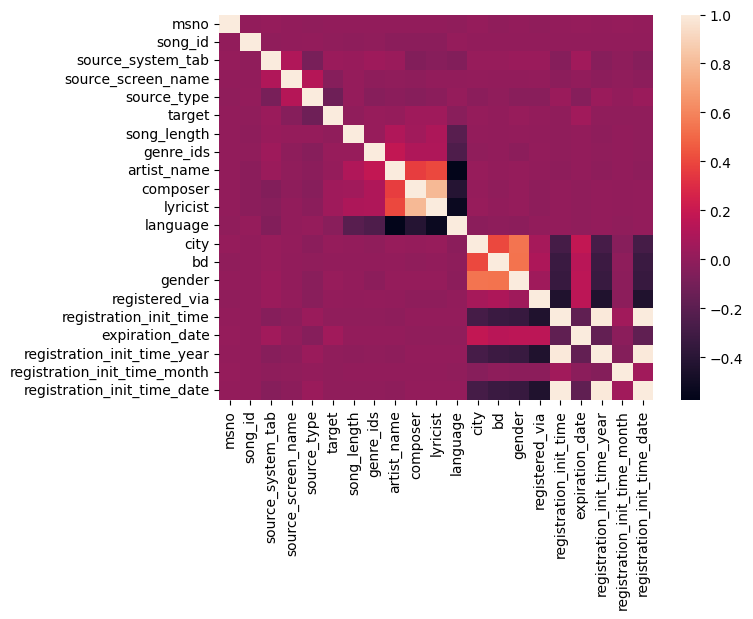

In [27]:
plt.figure(figsize=[7,5])
sns.heatmap(df.corr())
plt.show()

In [29]:
df = df.drop(['expiration_date', 'lyricist'], axis=1)